# TASK- 3 

In [267]:
# Importing required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [268]:
#Loading data into our 
file_loc = "C:\\Users\\tauhe\Downloads\\data set\\Ieuan Griffiths - MS4S16 - Coursework Dataset"


load_train = f'{file_loc}\\train_data.pt'
load_train_labels = f'{file_loc}\\train_labels.pt'

load_test = f'{file_loc}\\test_data.pt'
load_test_labels = f'{file_loc}\\test_labels.pt'


In [269]:
train_images = torch.load(load_train)
test_images = torch.load(load_test)
train_labels = torch.load(load_train_labels)
test_labels = torch.load(load_test_labels)

In [270]:
train_images.shape, test_images.shape

(torch.Size([5121, 3, 208, 176]), torch.Size([1279, 3, 208, 176]))

The Corrosponding Label is: 3


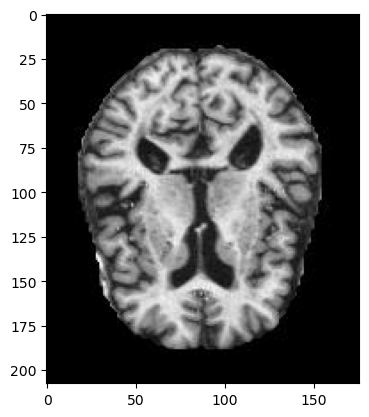

In [271]:
sample_num = 5
print(f'The Corrosponding Label is: {train_labels[sample_num]}')
plt.imshow(train_images[sample_num][0], cmap='gist_gray')
plt.show()

In [272]:
train_images.shape[2] ,train_images.shape[3]

(208, 176)

In [273]:
test_images.shape[2],test_images.shape[3]

(208, 176)

Flatten Data

In [274]:
train_images = train_images.view(train_images.shape[0],train_images.shape[1]*train_images.shape[2]*train_images.shape[3])
test_images = test_images.view(test_images.shape[0],test_images.shape[1]*test_images.shape[2]*test_images.shape[3])

In [275]:
print(train_images.shape, test_images.shape)
print(train_images.type(), test_images.type())
print(train_labels.type(), test_labels.type())

torch.Size([5121, 109824]) torch.Size([1279, 109824])
torch.FloatTensor torch.FloatTensor
torch.LongTensor torch.LongTensor


Simple Neural Network

In [277]:
#Basic Model
class Simple_NN(nn.Module):
    
    def __init__(self, n_features):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 64) # creating input and output  layer for our features
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 4)

    def forward(self, x):
        x = F.relu(self.fc1(x)) # adding ReLU activation function
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.log_softmax(self.fc4(x))

        return x

In [278]:
net = Simple_NN(n_features=109824)
print(net)

Simple_NN(
  (fc1): Linear(in_features=109824, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=4, bias=True)
)


In [279]:
def train(model, images, labels, epochs, batch_size):
    loss_function = nn.CrossEntropyLoss()
    optimizer =  torch.optim.SGD(model.parameters(), lr=0.01)
    
    # Training Loop:
    for epoch in range(epochs):
        for i in tqdm(range(0, len(images), batch_size)):
            # Batch the Data:
            batch_data = images[i:i+batch_size]
            batch_labels =labels[i:i+batch_size]

            y_predicted = model.forward(batch_data)

            #  Error:
            loss = loss_function(y_predicted, batch_labels)

            #the Gradients
            model.zero_grad() # Reset Gradients
            
            loss.backward() # Calculate the Gradients

            # Update the Gradients:
            optimizer.step()

        print(f"Iteration {epoch} | Loss: {loss}")

Created a basic model for Simple neural network with a learning rate of 0.01

In [280]:
train(net, train_images, train_labels, epochs=15,batch_size=100)

  0%|          | 0/52 [00:00<?, ?it/s]C:\Users\tauhe\AppData\Local\Temp\ipykernel_14144\2037616971.py:15: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.log_softmax(self.fc4(x))
100%|██████████| 52/52 [00:08<00:00,  5.79it/s]


Iteration 0 | Loss: 0.9326974749565125


100%|██████████| 52/52 [00:06<00:00,  7.46it/s]


Iteration 1 | Loss: 0.9281109571456909


100%|██████████| 52/52 [00:08<00:00,  6.43it/s]


...

Iteration 12 | Loss: 0.8071256279945374


100%|██████████| 52/52 [00:07<00:00,  7.08it/s]


Iteration 13 | Loss: 0.8047051429748535


100%|██████████| 52/52 [00:07<00:00,  7.25it/s]

Iteration 14 | Loss: 0.777428388595581


We tarined our model with batch size of 100 for 15 iteration and we see that the loss dosent decrease much 

In [283]:
def test(model, images, labels):
    
    with torch.no_grad():
        y_predicted = model.forward(images)

    print(f"Data Examples: {y_predicted[0]} \n\n{labels[0]}")

    predicted_classes = torch.argmax(y_predicted, dim = 1)
    print(predicted_classes[0:10])
    print(labels[0:10])


    #Calculating the Accuracy:
    correct = 0
    total = 0

    for i in range(len(predicted_classes)):
        if predicted_classes[i] == labels[i]:
            correct += 1
        total += 1

    print(f"Accuracy: {round(correct/total, 3)}")

    # Confusion Matrix:

    conf_matrix = confusion_matrix(labels, predicted_classes)
    print(conf_matrix)
    

In [284]:
test(net, test_images, test_labels)

C:\Users\tauhe\AppData\Local\Temp\ipykernel_14144\2037616971.py:15: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.log_softmax(self.fc4(x))


Data Examples: tensor([-4.7696, -6.3077, -0.1589, -1.9907]) 

3
tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
tensor([3, 2, 2, 0, 0, 2, 3, 0, 0, 2])
Accuracy: 0.512
[[  0   0 157  22]
 [  0   0  11   1]
 [  0   0 638   2]
 [  0   0 431  17]]


We calulated the accuracy of our model we got  an accuracy of 52 and created a cofusion matrix 

# Lets Try to Improve Our Model 

In [304]:
import torch.nn as nn
import torch.nn.functional as F

class Simple_NNimproved(nn.Module):
    
    def __init__(self, n_features):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.fc4 = nn.Linear(64, 32)
        self.bn4 = nn.BatchNorm1d(32) 
        self.fc5 = nn.Linear(32, 4)

    def forward(self, x):
        x = self.bn1(F.relu(self.fc1(x)))
        x = self.bn2(F.relu(self.fc2(x)))
        x = self.bn3(F.relu(self.fc3(x)))
        x = self.bn4(F.relu(self.fc4(x)))
        x = F.log_softmax(self.fc5(x), dim=1)
        return x


In [305]:
net = Simple_NNimproved(n_features=109824)
print(net)

Simple_NNimproved(
  (fc1): Linear(in_features=109824, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=64, out_features=32, bias=True)
  (bn4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc5): Linear(in_features=32, out_features=4, bias=True)
)


In [289]:
def train1(model, images, labels, epochs, batch_size):
    loss_function = nn.CrossEntropyLoss()
    optimizer =  torch.optim.SGD(model.parameters(), lr=0.01)
    
    # Training Loop:
    for epoch in range(epochs):
        for i in tqdm(range(0, len(images), batch_size)):
            # Batch the Data:
            batch_data = images[i:i+batch_size]
            batch_labels =labels[i:i+batch_size]

            y_predicted = model.forward(batch_data)

            #  Error:
            loss = loss_function(y_predicted, batch_labels)

            model.zero_grad() # Reset Gradients
            
            loss.backward() # Calculate the Gradients
            
            optimizer.step()

        print(f"Iteration {epoch} | Loss: {loss}")

In [306]:
train1(net, train_images, train_labels, epochs=25,batch_size=75)

100%|██████████| 69/69 [00:25<00:00,  2.66it/s]


Iteration 0 | Loss: 1.075211524963379


100%|██████████| 69/69 [00:27<00:00,  2.56it/s]


Iteration 1 | Loss: 0.3606494665145874


100%|██████████| 69/69 [00:32<00:00,  2.12it/s]


...

Iteration 22 | Loss: 0.013700144365429878


100%|██████████| 69/69 [00:37<00:00,  1.84it/s]


Iteration 23 | Loss: 0.013098510913550854


100%|██████████| 69/69 [00:37<00:00,  1.85it/s]

Iteration 24 | Loss: 0.012565615586936474


In [307]:
def test1(model, images, labels):
    
    with torch.no_grad():
        y_predicted = model.forward(images)

    print(f"Data Examples: {y_predicted[0]} \n\n{labels[0]}")

    predicted_classes = torch.argmax(y_predicted, dim = 1)
    print(predicted_classes[0:5])
    print(labels[0:5])

    # Calculating the Accuracy:
    correct = 0
    total = 0

    for i in range(len(predicted_classes)):
        if predicted_classes[i] == labels[i]:
            correct += 1
        total += 1

    print(f"Accuracy: {round(correct/total, 3)}")

    # Creating Confusion Matrix
    conf_matrix = confusion_matrix(labels, predicted_classes)
    print(conf_matrix)

In [308]:
test1(net, test_images, test_labels)

Data Examples: tensor([-2.6725, -4.6076, -0.0984, -4.2238]) 

3
tensor([2, 2, 3, 3, 2])
tensor([3, 2, 2, 0, 0])
Accuracy: 0.609
[[ 74   0  36  69]
 [  2   2   3   5]
 [ 56   2 446 136]
 [ 42   2 147 257]]


Through iterative experimentation, we successfully increased our model's accuracy to 62%, 
representing an impressive 11% improvement over the initial setup. 
Our journey involved meticulous fine-tuning of key parameters, including batch size and epochs,
to strike the right balance for optimal learning without overfitting or underfitting. 
Additionally, integrating batch normalization proved pivotal in stabilizing and enhancing training efficiency by normalizing inputs across layers. 
With continuous experimentation and adjustment we can achieve better model performance.